# Prosjektoppgave PY1010
### Ann Cathrin Langfeldt


In [1]:
#Del a) 

#Importere pandas bibliotek for å kunne hente inn excelfil (datasett)
import pandas as pd

#Leser inn Excel filen med data for uke 24
morse_uke24 = "support_uke_24.xlsx"
data = pd.read_excel(morse_uke24)

#Konverterer kolonner fra datasettet til NumPy-arrays.
u_dag = data ["Ukedag"].values #Ukedag henvendelsen fant sted
kl_slett = data ["Klokkeslett"].values #Klokkeslett kunden tok kontakt med supportavdelingen
varighet = data ["Varighet"].values #Samtalens varighet
score = data ["Tilfredshet"].values #Kundens tilfredshet

#Skriver ut arrayene. 
print(u_dag)
print(kl_slett)
print(varighet)
print(score)


['Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag' 'Mandag'
 'Mandag' 'Mandag' 'Mandag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag'
 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Tirsdag' 'Onsdag' 'Onsdag'
 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsdag' 'Onsda

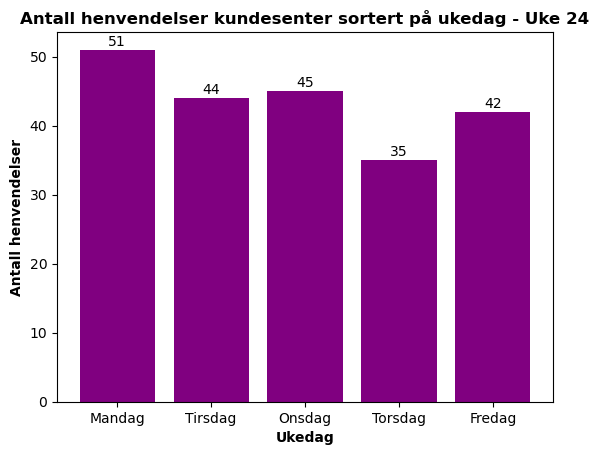

In [2]:
#Del b) 

#importerer matplotlib bibliotek for å kunne lage stolpediagram 
import matplotlib.pyplot as plt

#oppretter dictionary for å telle antall henvendelser per dag
antall_per_dag ={} #Oppretter en tom dicitionary 
for dag in u_dag:           #Går gjennom u_dag array
    if dag in antall_per_dag:
        antall_per_dag[dag] += 1  #Dersom ukedagen eksisterer i dictionaty økes antall med 1.  
    else:
        antall_per_dag[dag] = 1   #Dersom ukendagen ikke eksisterer i dicitonaty legges den til med antall 1. 

#Konverterer dictionary til lister som kan brukes i stolpediagram
dager = list(antall_per_dag.keys())
antall = list(antall_per_dag.values())

#Lager stolpediagram
bars = plt.bar(dager, antall, color="purple") #Beskriver at ukedager skal være på x-aksen, og at antall henvendelser skal være på y-aksen. Farger diagrammet lilla.
plt.xlabel("Ukedag", fontweight='bold') #setter inn navn på x-aksen
plt.ylabel("Antall henvendelser", fontweight='bold') #setter inn navn på y-aksen
plt.title("Antall henvendelser kundesenter sortert på ukedag - Uke 24",  fontweight='bold') #setter inn navn på diagram
plt.bar_label(bars, padding=1) #legger antall henvendelser i toppen av stolpene
plt.show() #skeriver ut stolpediagram

In [3]:
#Del c) 

#Finner lengste og korteste samtale i array "varighet". 
korteste = min(varighet) 
lengste = max(varighet)

#Lager funksjon som:
#formaterer data fra HH:MM:SS til timer, minutter og sekunder, og definerer data som heltall med bruk av map-funksjon. 
#returnerer data i lesbart format, som bare tar med timer eller minutter dersom samtalen har vart i timer eller minutter. 
def formater_tid(tid):
    timer, minutter, sekunder = map(int, tid.split(":"))

    if timer == 0 and minutter == 0:
        return f"{sekunder} sekunder" #Retunerer sekunder dersom timer og minutter er 0 
    elif timer == 0:
        return f"{minutter} minutter og {sekunder} sekunder" #Retunerer minutter og sekunder dersom timer er 0
    else:
        return f"{timer}timer, {minutter} minutter og {sekunder} sekunder" #retnunerer timer, minutter og sekunder 


#Skriver ut den korteste og lengste samtalen i lesbart format ved å bruke "formater_tid" funksjonen. 
print ("Den korteste samtalen til MORSE i Uke 24 var", formater_tid(korteste),",",  "og den lengste samtalen var", formater_tid(lengste))



Den korteste samtalen til MORSE i Uke 24 var 59 sekunder , og den lengste samtalen var 11 minutter og 28 sekunder


In [4]:
#Del d)

#Importer numpy bibliotek for å kunne bruke gjennomsnitt funksjon.
import numpy as np

#Lager formel som omgjør tid i format HH:MM:SS til sekunder. 
#Formelen bruker map-funksjonen for å dele opp tid, og caste elementene fra string til heltall
#retunerer totalt antall sekunder i hvert element.
def tid_til_sekunder (tid):
    timer, minutter, sekunder = map(int, tid.split(":"))
    return timer * 3600 + minutter * 60 + sekunder 

#Gjør om alle samtaletider i array "varighet" til sekunder med bruk av formel "tid_til_sekunder" 
varighet_i_sek = [tid_til_sekunder(samtaletid) for samtaletid in varighet]


#Finner gjennomsnittlig samtaletid i hele sekunder.
gjennomsnitt_sek = np.mean(varighet_i_sek) #finner gjennomsnittet i sekunder
gjennomsnitt_sek_avrundet = int(gjennomsnitt_sek) #skriver om gjenomsnittet til heltall

#Skriver om gjenomsnitt i sekunder til minutter og sekunder for lesbar tekst
minutter = gjennomsnitt_sek_avrundet //60 #Regner ut hvor mange hele minutter gjennomsnittlig samtaletid tilsvarer
sekunder = gjennomsnitt_sek_avrundet %60 #Regner ut hvor mange sekunder som er igjen etter å ha trukket fra hele minutter

#Skriver ut gjenomsnittlig samtaletid med beskrivende tekst
print("Gjennomsnittlig samtaletid i uke 24 for kundesenteret på MORSE var", minutter,"minutter og", sekunder, "sekunder")




Gjennomsnittlig samtaletid i uke 24 for kundesenteret på MORSE var 6 minutter og 40 sekunder


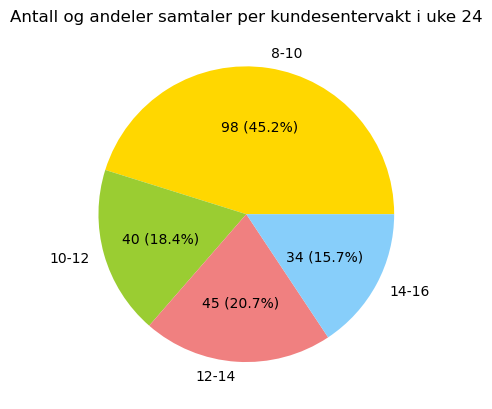

In [5]:
#Del e) 

#Initialiser tellere for hver 2-timers supportvakt.
ant_1_vakt = 0  #teller antall henvendelser mellom 08:00 og 10:00
ant_2_vakt = 0  #teller antall henvendelser mellom 10:00 og 12:00
ant_3_vakt = 0  #teller antall henvendelser mellom 12:00 og 14:00
ant_4_vakt = 0  #teller antall henvendelser mellom 14:00 og 16:00

#For-løkke som går gjennom alle tidspunktene i listen kl_slett og teller antall henvendelser for de uliek supportvaktene.
for tid in kl_slett:
    time = int(tid.split(":")[0]) #henter timen fra tidspunktene ved å splitte HH:MM:SS formatet, hente ut timen fra indeks 0, og konvertere den til heltall 

    # Går gjennom klokkeslett og teller hvilken vakt samtalen tilhører, øker relevant teller ut fra hvilke supportvakt samtalen tilhører.
    if 8 <= time < 10:
        ant_1_vakt += 1 #øker teller "ant_1_vakt" dersom samtalen ble logget mellom 8-10
    elif 10 <= time < 12:
        ant_2_vakt += 1 #øker teller "ant_2_vakt" dersom samtalen ble logget mellom 10-12
    elif 12 <= time <14: 
        ant_3_vakt += 1 #øker teller "ant_3_vakt" dersom samtalen ble logget mellom 12-14
    else:
        ant_4_vakt += 1 #øker teller "ant_4_vakt" dersom samtalen fant sted utenfor tidsrommet 8-14
        

ant_per_vakt = [ant_1_vakt, ant_2_vakt, ant_3_vakt, ant_4_vakt]

#formaterer innhold til diagram 
tekst = ["8-10", "10-12", "12-14", "14-16"] #definerer variabelen tekst til de ulike tidspunketne for vaktene
farger = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue'] #Definerer farger i diagrammet 

#funksjon for å kunne vise antall og prosent i diagram
def vis_antall_prosent(p):
    total = sum(ant_per_vakt)        # totalt antall samtaler
    antall = int(p * total / 100)    # regner ut antallet for de ulike delene av diagrammet  
    return f"{antall} ({p:.1f}%)"    # retunerer antall og prosent

plt.pie(
    ant_per_vakt,  #Definerer hvilken data sektordiagram skal bruke
    labels=tekst,  #Setter på tekst for å beskrive hvilken vakt "kakestykke" visualiserer
    colors=farger, #Beskriver at sektordiagram skal bruke fargene fra variabelen "farger"
    autopct=vis_antall_prosent #Bruker formelen "vis_antall_prosent" for å sette inn antall og prosentandel av samtaler i diagrammet. 
)
plt.title("Antall og andeler samtaler per kundesentervakt i uke 24")  #legger til tittel på diagrammet
plt.show()

